In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             roc_auc_score, f1_score, matthews_corrcoef, balanced_accuracy_score, recall_score)
from sklearn.metrics import average_precision_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('data_for_ML-tgShifted.parquet')
df = df.sort_values('datetime').reset_index(drop=True)

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('int32')

print(f"Shape: {df.shape}")
print( f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MG")

Shape: (808940, 231)
Memory: 758.7 MG


In [3]:
for lag in [24, 48, 72, 168]:
    df[f'alarms_lag_{lag}h'] = (
        df.groupby('region_id')['alarms_last_24h'].shift(lag)
    )

df['alarms_rolling_24h_mean'] = (
    df.groupby('region_id')['alarms_last_24h']
    .transform(lambda x: x.shift(24).rolling(24).mean())
)

df = df.dropna().reset_index(drop=True)

drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season',
             'regions_in_alarm_now', 'alarms_last_24h']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df['alarm']

val_idx   = int(len(df) * 0.6)
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:val_idx]
X_val   = X.iloc[val_idx:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:val_idx]
y_val   = y.iloc[val_idx:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape}: {df['datetime'].iloc[0]} - {df['datetime'].iloc[val_idx]}")
print(f"Val:   {X_val.shape}: {df['datetime'].iloc[val_idx]} - {df['datetime'].iloc[split_idx]}")
print(f"Test:  {X_test.shape}: {df['datetime'].iloc[split_idx]} - {df['datetime'].iloc[-1]}")

Train: (483045, 227): 2022-03-03 00:00:00 - 2024-07-25 03:00:00
Val:   (161015, 227): 2024-07-25 03:00:00 - 2025-05-16 02:00:00
Test:  (161016, 227): 2025-05-16 02:00:00 - 2026-03-16 23:00:00


In [4]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print("Time Series Cross-Validation:")
print(f"{'Fold':<6} {'Train size':<12} {'Test size':<12} {'ROC-AUC'}")
print("-" * 45)

cv_scores = []

for fold, (train_idx, val_idx_cv) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx_cv]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx_cv]
    
    scaler_cv = StandardScaler()
    X_fold_train_s = scaler_cv.fit_transform(X_fold_train)
    X_fold_val_s   = scaler_cv.transform(X_fold_val)
    
    model_cv = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        max_iter=50,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    model_cv.fit(X_fold_train_s, y_fold_train)
    y_prob_cv = model_cv.predict_proba(X_fold_val_s)[:, 1]
    score = roc_auc_score(y_fold_val, y_prob_cv)
    cv_scores.append(score)
    
    print(f"Fold {fold:<4} {len(train_idx):<12} {len(val_idx_cv):<12} {score:.4f}")

print("-" * 45)
print(f"{'Mean':<18} {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Time Series Cross-Validation:
Fold   Train size   Test size    ROC-AUC
---------------------------------------------
Fold 1    80510        80507        0.6041
Fold 2    161017       80507        0.6487
Fold 3    241524       80507        0.5767
Fold 4    322031       80507        0.6870
Fold 5    402538       80507        0.6792
---------------------------------------------
Mean               0.6391 ± 0.0427


In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)   
X_test_s  = scaler.transform(X_test)

In [6]:
for layers in [(128, 64), (256, 128), (256, 128, 64)]:
    model = MLPClassifier(
        hidden_layer_sizes=layers, max_iter=50,
        early_stopping=True, validation_fraction=0.1,
        random_state=42
    )
    model.fit(X_train_s, y_train)
    y_prob_val = model.predict_proba(X_val_s)[:, 1]  
    print(f"layers={layers} and ROC-AUC: {roc_auc_score(y_val, y_prob_val):.4f}")

layers=(128, 64) and ROC-AUC: 0.7125
layers=(256, 128) and ROC-AUC: 0.7340
layers=(256, 128, 64) and ROC-AUC: 0.6709


In [16]:
model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
model.fit(X_train_s, y_train)
y_prob_val = model.predict_proba(X_val_s)[:, 1]
print(f"ROC-AUC (val): {roc_auc_score(y_val, y_prob_val):.4f}")

ROC-AUC (val): 0.7340


In [21]:
y_prob_val = model.predict_proba(X_val_s)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_global_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (from validation): {best_global_threshold:.3f}")

X_val_meta = pd.DataFrame({
    'y_true': y_val.values,
    'y_prob': y_prob_val
})


val_start = int(len(df) * 0.6)
X_val_meta['region_id'] = df.iloc[val_start:split_idx]['region_id'].values


regional_thresholds = {}
for region in X_val_meta['region_id'].unique():
    mask = X_val_meta['region_id'] == region
    y_t = X_val_meta.loc[mask, 'y_true']
    y_p = X_val_meta.loc[mask, 'y_prob']
    
    if y_t.sum() == 0:
        regional_thresholds[region] = best_global_threshold
        continue
    
    best_thresh_reg = 0.01 
    
    for thresh in np.arange(0.50, 0.004, -0.005): 
        y_pred = (y_p >= thresh).astype(int)
        r = recall_score(y_t, y_pred, zero_division=0)
        if r >= 0.80:
            best_thresh_reg = round(thresh, 3) 
            
    regional_thresholds[region] = best_thresh_reg
    print(f"Region {region:<2}: threshold = {best_thresh_reg:.3f}")

y_prob = model.predict_proba(X_test_s)[:, 1]
test_regions = df.iloc[split_idx:]['region_id'].values


y_pred_final = np.array([
    int(p >= regional_thresholds.get(r, best_global_threshold))
    for p, r in zip(y_prob, test_regions)
])

print("\n Final metrics on the TEST ")
print(classification_report(y_test, y_pred_final, target_names=['No Alarm', 'Alarm']))
print(f"Accuracy:          {accuracy_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:            {average_precision_score(y_test, y_prob):.4f}")
print(f"F1:                {f1_score(y_test, y_pred_final):.4f}")
print(f"MCC:               {matthews_corrcoef(y_test, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_final):.4f}")

Optimal threshold (from validation): 0.022
Region 4 : threshold = 0.010
Region 7 : threshold = 0.010
Region 24: threshold = 0.010
Region 11: threshold = 0.010
Region 23: threshold = 0.005
Region 14: threshold = 0.010
Region 10: threshold = 0.005
Region 25: threshold = 0.020
Region 16: threshold = 0.030
Region 6 : threshold = 0.010
Region 3 : threshold = 0.010
Region 8 : threshold = 0.010
Region 13: threshold = 0.010
Region 21: threshold = 0.010
Region 5 : threshold = 0.045
Region 2 : threshold = 0.010
Region 15: threshold = 0.010
Region 17: threshold = 0.010
Region 19: threshold = 0.010
Region 18: threshold = 0.080
Region 20: threshold = 0.055
Region 22: threshold = 0.010
Region 9 : threshold = 0.010

 Final metrics on the TEST 
              precision    recall  f1-score   support

    No Alarm       0.85      0.62      0.72    114666
       Alarm       0.44      0.73      0.55     46350

    accuracy                           0.65    161016
   macro avg       0.64      0.67      0.63

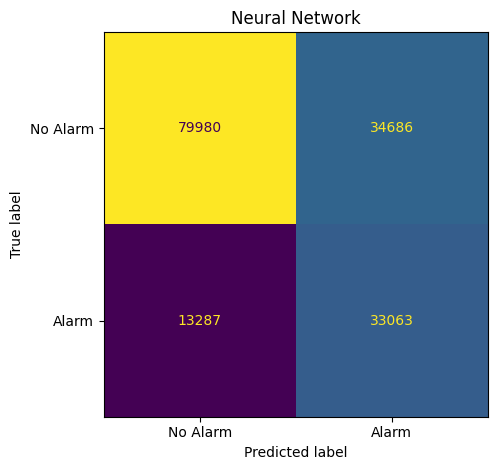

In [14]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Alarm', 'Alarm'])
disp.plot(colorbar=False, values_format='d')
plt.title('Neural Network')
plt.tight_layout()
plt.show()

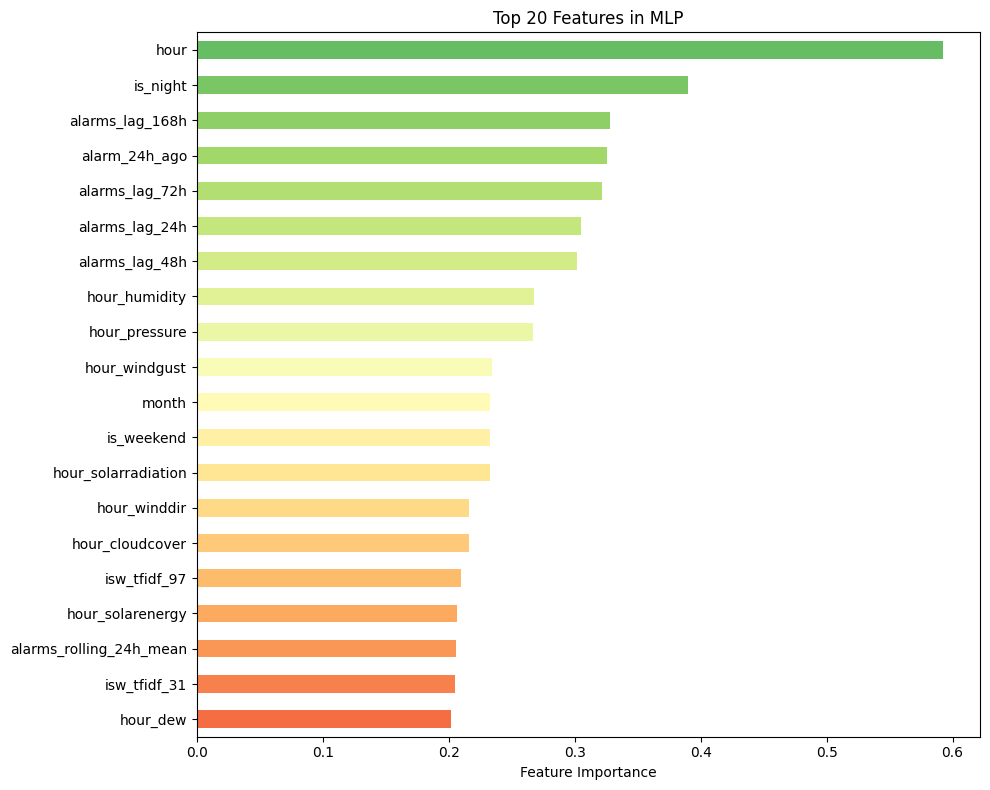

In [22]:
weights = np.abs(model.coefs_[0]).mean(axis=1)
feat_imp = pd.Series(weights, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 20))
top20.sort_values().plot(kind='barh', color=colors)
plt.title('Top 20 Features in MLP')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [11]:
with open('6__mlp__v1.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'scaler': scaler,         
        'threshold': float(best_threshold)
    }, f)